In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [3]:
sales = pd.read_csv("C:\\Users\\RIDA SHARIFF\\Downloads\\AI_Price_Optima\\AI_Price_Optima\\data\\processed\\sales_cleaned.csv")
inventory = pd.read_csv("C:\\Users\\RIDA SHARIFF\\Downloads\\AI_Price_Optima\\AI_Price_Optima\\data\\processed\\inventory_cleaned.csv")

sales["date"] = pd.to_datetime(sales["date"])

sales.head()

,order_id,product_id,date,quantity,price
0,1001,P101,2026-03-01,2,499.99
1,1002,P102,2026-03-01,1,899.50
2,1003,P103,2026-03-02,3,299.99
3,1004,P101,2026-03-02,1,499.99
4,1005,P104,2026-03-03,5,149.99


In [4]:
sales.info()
sales.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    10 non-null     int64         
 1   product_id  10 non-null     object        
 2   date        10 non-null     datetime64[ns]
 3   quantity    10 non-null     int64         
 4   price       10 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 532.0+ bytes


,order_id,date,quantity,price
count,10.00000,10,10.000000,10.000000
mean,1005.50000,2026-03-03 00:00:00,2.400000,427.892000
min,1001.00000,2026-03-01 00:00:00,1.000000,79.990000
25%,1003.25000,2026-03-02 00:00:00,1.250000,187.490000
50%,1005.50000,2026-03-03 00:00:00,2.000000,399.990000
75%,1007.75000,2026-03-04 00:00:00,3.000000,499.990000
max,1010.00000,2026-03-05 00:00:00,5.000000,899.500000
std,3.02765,NaN,1.349897,292.239488


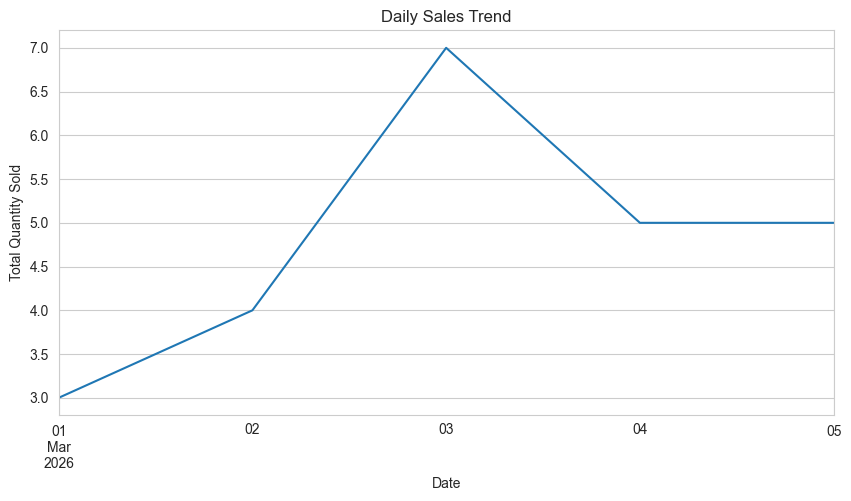

In [5]:
daily_sales = sales.groupby("date")["quantity"].sum()

daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.show()

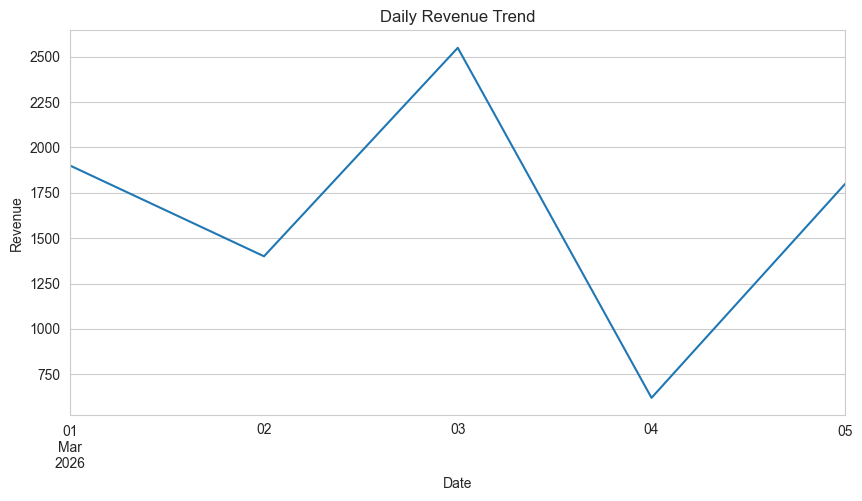

In [6]:
sales["revenue"] = sales["quantity"] * sales["price"]
daily_revenue = sales.groupby("date")["revenue"].sum()

daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

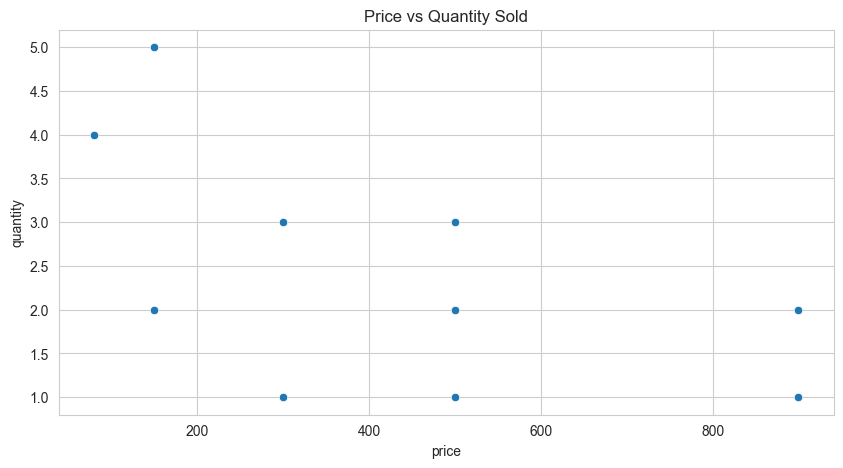

In [7]:
sns.scatterplot(data=sales, x="price", y="quantity")
plt.title("Price vs Quantity Sold")
plt.show()

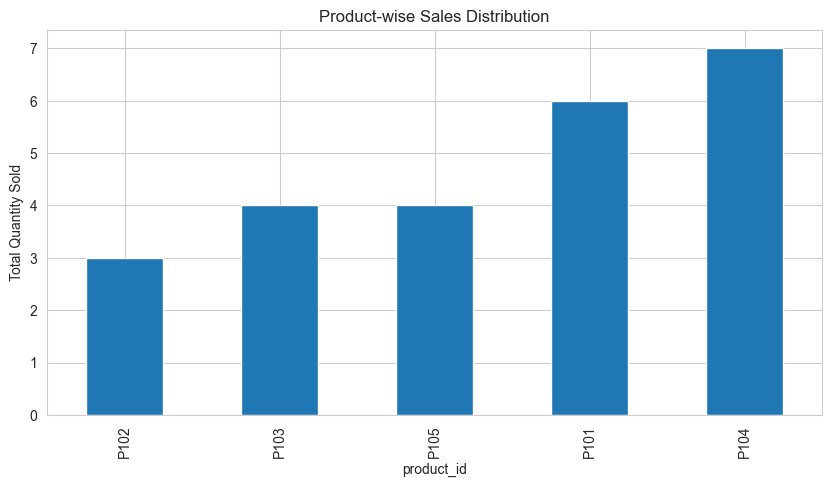

In [8]:
product_sales = sales.groupby("product_id")["quantity"].sum()

product_sales.sort_values().plot(kind="bar")
plt.title("Product-wise Sales Distribution")
plt.ylabel("Total Quantity Sold")
plt.show()

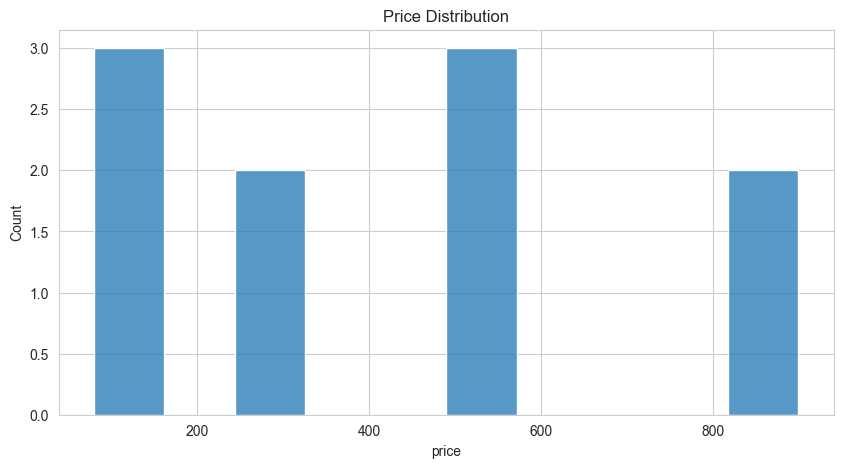

In [9]:
sns.histplot(sales["price"], bins=10)
plt.title("Price Distribution")
plt.show()

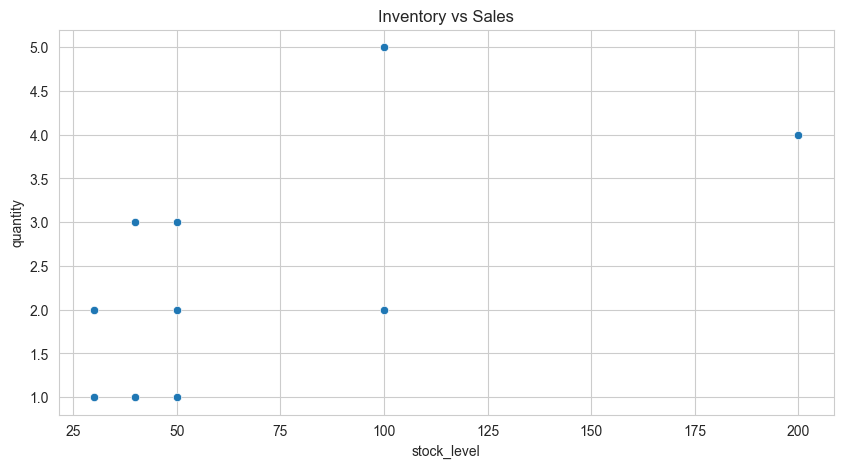

In [10]:
merged = sales.merge(inventory, on="product_id", how="left")

sns.scatterplot(data=merged, x="stock_level", y="quantity")
plt.title("Inventory vs Sales")
plt.show()

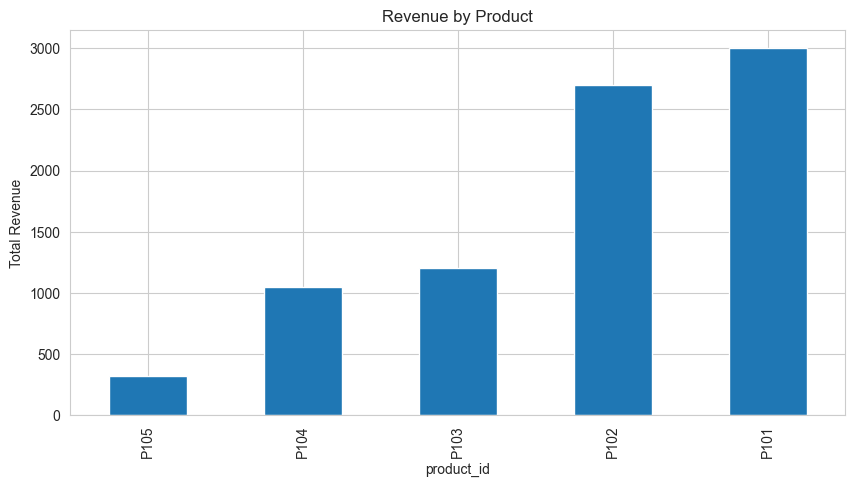

In [11]:
product_revenue = sales.groupby("product_id")["revenue"].sum()

product_revenue.sort_values().plot(kind="bar")
plt.title("Revenue by Product")
plt.ylabel("Total Revenue")
plt.show()

In [12]:
summary = sales.groupby("product_id").agg({
    "quantity":"sum",
    "revenue":"sum"
}).reset_index()

summary["demand_segment"] = pd.qcut(summary["quantity"], 3,
                                    labels=["Low","Medium","High"])

summary

,product_id,quantity,revenue,demand_segment
0,P101,6,2999.94,High
1,P102,3,2698.50,Low
2,P103,4,1199.96,Low
3,P104,7,1049.93,High
4,P105,4,319.96,Low
